# The "aprox13" network

The aprox13 network is widely used for explosive He burning in multidimensional simulations.  It has 2 main approximations:

* C+C, C+O, and O+O burning are simplied, removing the intermediate nucleus from the proton emission branch and neglecting the neutron-emission branch
* The $(\alpha,p)(p,\gamma)$ links are combined with $(\alpha,\gamma)$

We can do both approximations.

## A starting network

To begin, we'll create a network will all of the nuclei (including those that will be approximated out later).  We'll use {py:func}`network_helper <pynucastro.networks.helper.network_helper>` so we automatically rederive reverse rates using detailed balance.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"])

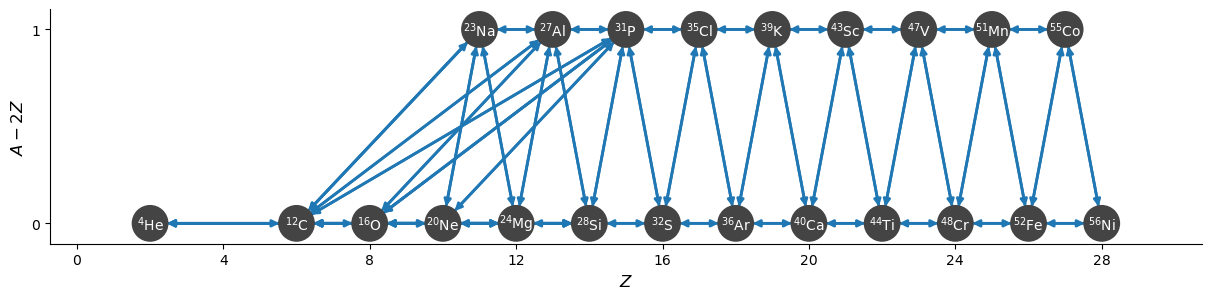

In [3]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1200, 300), node_size=600, node_font_size=10)

In [4]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 23
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 92

  rates explicitly connecting nuclei: 92
  hidden rates: 0

  reaclib rates: 46
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 46
  modified rates: 0
  custom rates: 0


## Approximating

Now we'll approximate the C/O burning

In [5]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [6]:
approx_net = pyna.PythonNetwork(rates=net.get_rates())

In [7]:
new_rates, old_rate_str = make_CO_approx_rates(approx_net.get_rates(), "C", return_obsolete_rate_names=True)
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["na23"])

C12 C12 Ne20 Mg24 Na23


In [8]:
new_rates, old_rate_str = make_CO_approx_rates(approx_net.get_rates(), "CO", return_obsolete_rate_names=True)
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["al27"])

C12 O16 Mg24 Si28 Al27


In [9]:
new_rates, old_rate_str = make_CO_approx_rates(approx_net.get_rates(), "O", return_obsolete_rate_names=True)
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["p31"])

O16 O16 Si28 S32 P31


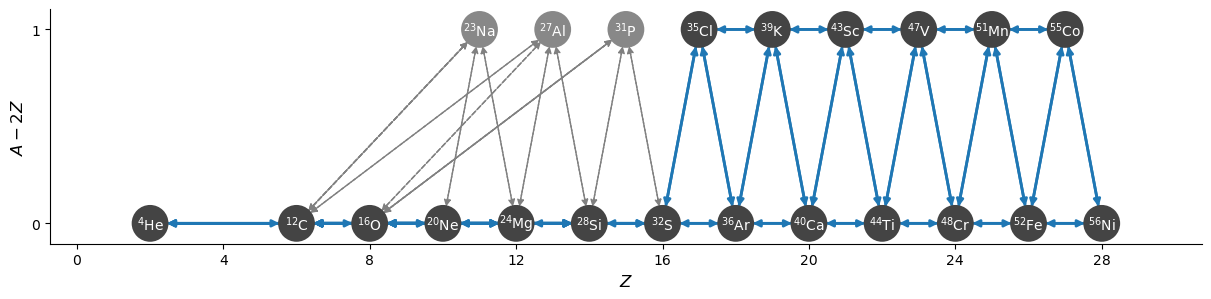

In [10]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

now the $(\alpha,p)(p,\gamma)$ approximation

In [11]:
approx_net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
approx_net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

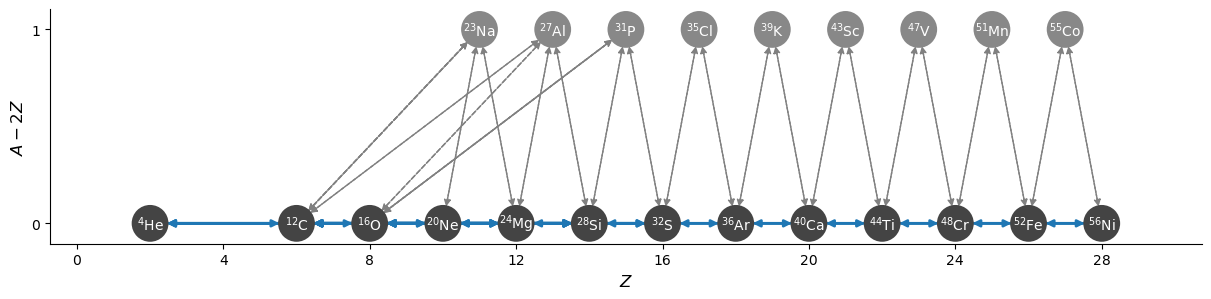

In [12]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

## Comparing the integration

### the full network

In [17]:
import numpy as np
from scipy.integrate import solve_ivp

In [18]:
net.write_network("full_aprox13.py")
import full_aprox13 as fn

In [20]:
rho = 1.e7
T = 3.e9

X0 = np.zeros(fn.nnuc)
X0[fn.jhe4] = 1.0

Y0 = X0 / fn.A

In [23]:
tmax = 1000.0

sol_full = solve_ivp(fn.rhs, [0, tmax], Y0, method="BDF", jac=fn.jacobian,
                     dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

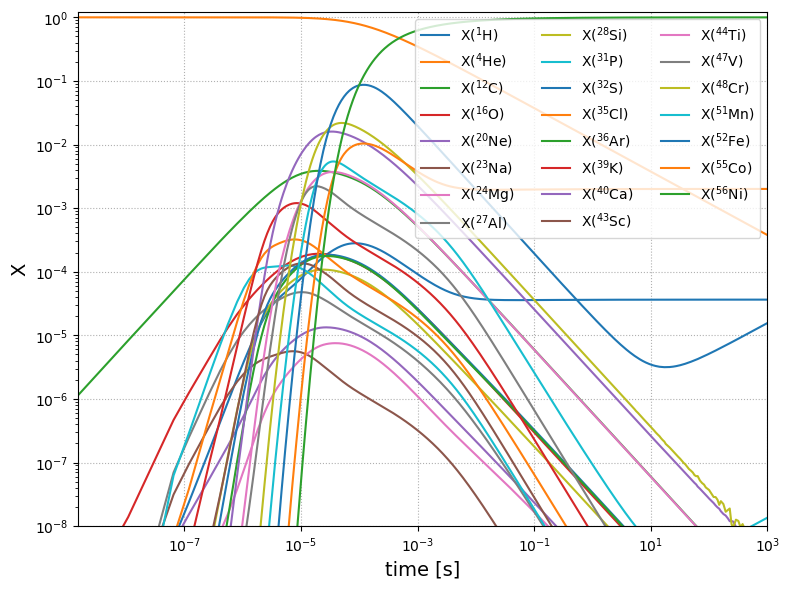

In [24]:
fig = net.plot_evolution(sol_full, ymin=1.e-8)

### aprox13 net

In [34]:
approx_net.write_network("aprox13.py")
import aprox13 as ap

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [35]:
X0 = np.zeros(ap.nnuc)
X0[ap.jhe4] = 1.0

Y0 = X0 / ap.A

In [36]:
sol_approx = solve_ivp(ap.rhs, [0, tmax], Y0, method="BDF", jac=ap.jacobian,
                       dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

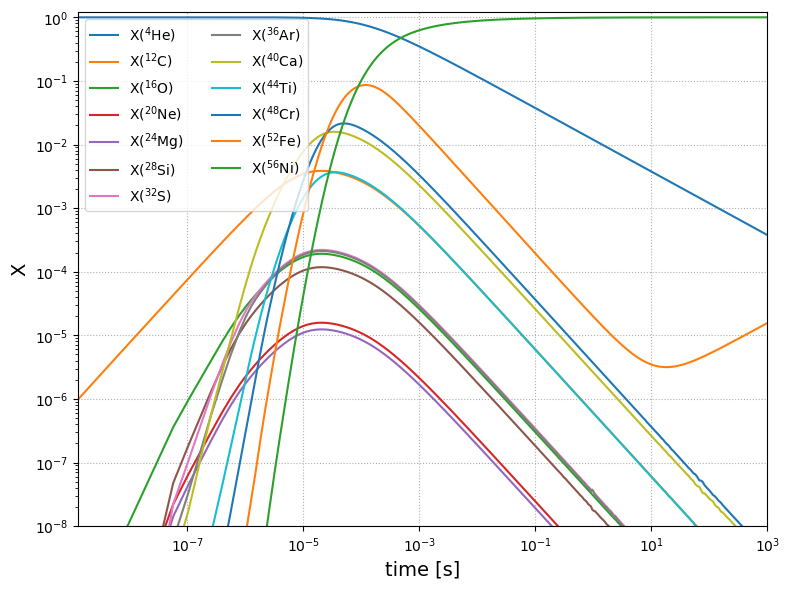

In [37]:
fig = approx_net.plot_evolution(sol_approx, ymin=1.e-8)

### Comparing

In [38]:
import matplotlib.pyplot as plt

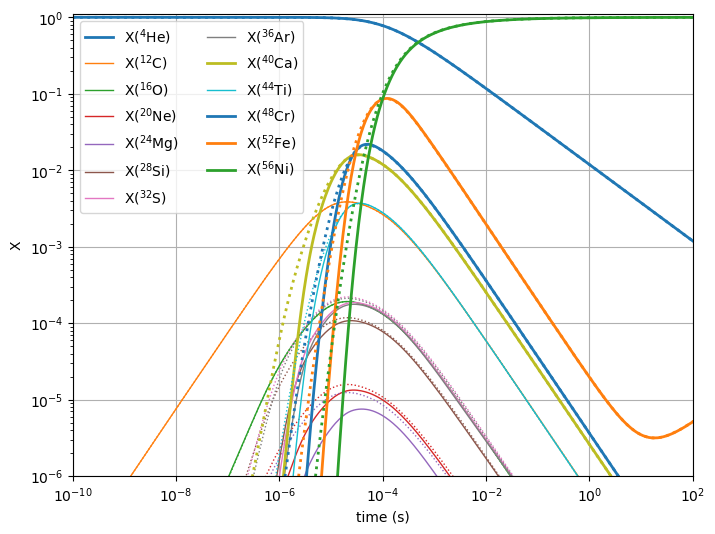

In [43]:
fig, ax = plt.subplots()

for i in range(ap.nnuc):
    lw = 1
    if (sol_approx.y[i,:] * ap.A[i]).max() > 1.e-2:
        lw = 2
    ax.loglog(sol_approx.t, sol_approx.y[i,:] * ap.A[i],
              linestyle=":", color=f"C{i}", lw=lw)    
    idx = fn.names.index(ap.names[i])
    ax.loglog(sol_full.t, sol_full.y[idx,:] * fn.A[idx],
              label=rf"X$({pyna.Nucleus(fn.names[idx]).pretty})$",              
              linestyle="-", color=f"C{i}", lw=lw)

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-10, 100)
fig.set_size_inches((8,6))
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend(ncol=2)
ax.grid()

We see good agreement for the nuclei the two networks have in common.